# Домашнее задание #3: исследование KNNДомашнее задание #3: исследование KNN
Цель задания — самостоятельно исследовать метод k-ближайших соседей (KNN) на реальном датасете и сравнить его с несколькими базовыми
моделями.  
Задача — пройти основные этапы небольшого ML-проекта и понять, когда KNN работает хорошо, а когда — хуже других моделейкогда KNN работает хорошо

In [19]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

## 1) Выбор датасета.
Ничего придумывать не стал и взял Iris Species

In [20]:
df = pd.read_csv("Iris.csv")

## 2) Первичный анализ данных

In [21]:
display(df.head())
display(df.dtypes)
display(df.isnull().sum())
display(df.info())
display(df.describe())
display(df['Species'].value_counts())

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


Id                 int64
SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species              str
dtype: object

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


None

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

## 3. Подготовка данных

In [22]:
float_columns = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
str_columns = ['Species']

scaler = MinMaxScaler()
X = pd.DataFrame(scaler.fit_transform(df[float_columns]))
X.columns = float_columns
X.insert(0, 'Id', df['Id'])

encoder = LabelEncoder()
y = pd.DataFrame(encoder.fit_transform(df[str_columns]))
y.columns = str_columns
y.insert(0, 'Id', df['Id'])

display(X)
display(y)

/home/dd/ml-course-homeworks/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,1,0.222222,0.625000,0.067797,0.041667
1,2,0.166667,0.416667,0.067797,0.041667
2,3,0.111111,0.500000,0.050847,0.041667
3,4,0.083333,0.458333,0.084746,0.041667
4,5,0.194444,0.666667,0.067797,0.041667
...,...,...,...,...,...
145,146,0.666667,0.416667,0.711864,0.916667
146,147,0.555556,0.208333,0.677966,0.750000
147,148,0.611111,0.416667,0.711864,0.791667
148,149,0.527778,0.583333,0.745763,0.916667


,Id,Species
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0
...,...,...
145,146,2
146,147,2
147,148,2
148,149,2


## 4. Feature enginnering
Новые фичи: площадь лепестка, площадь чашелистика, общая площадь цветка

In [23]:
X['PetalSquare'] = X['PetalLengthCm'] * X['PetalWidthCm']
X['SepalSquare'] = X['SepalLengthCm'] * X['SepalWidthCm']
X['Square'] = X['SepalSquare'] + X['PetalSquare']

## 5. Визуализация 

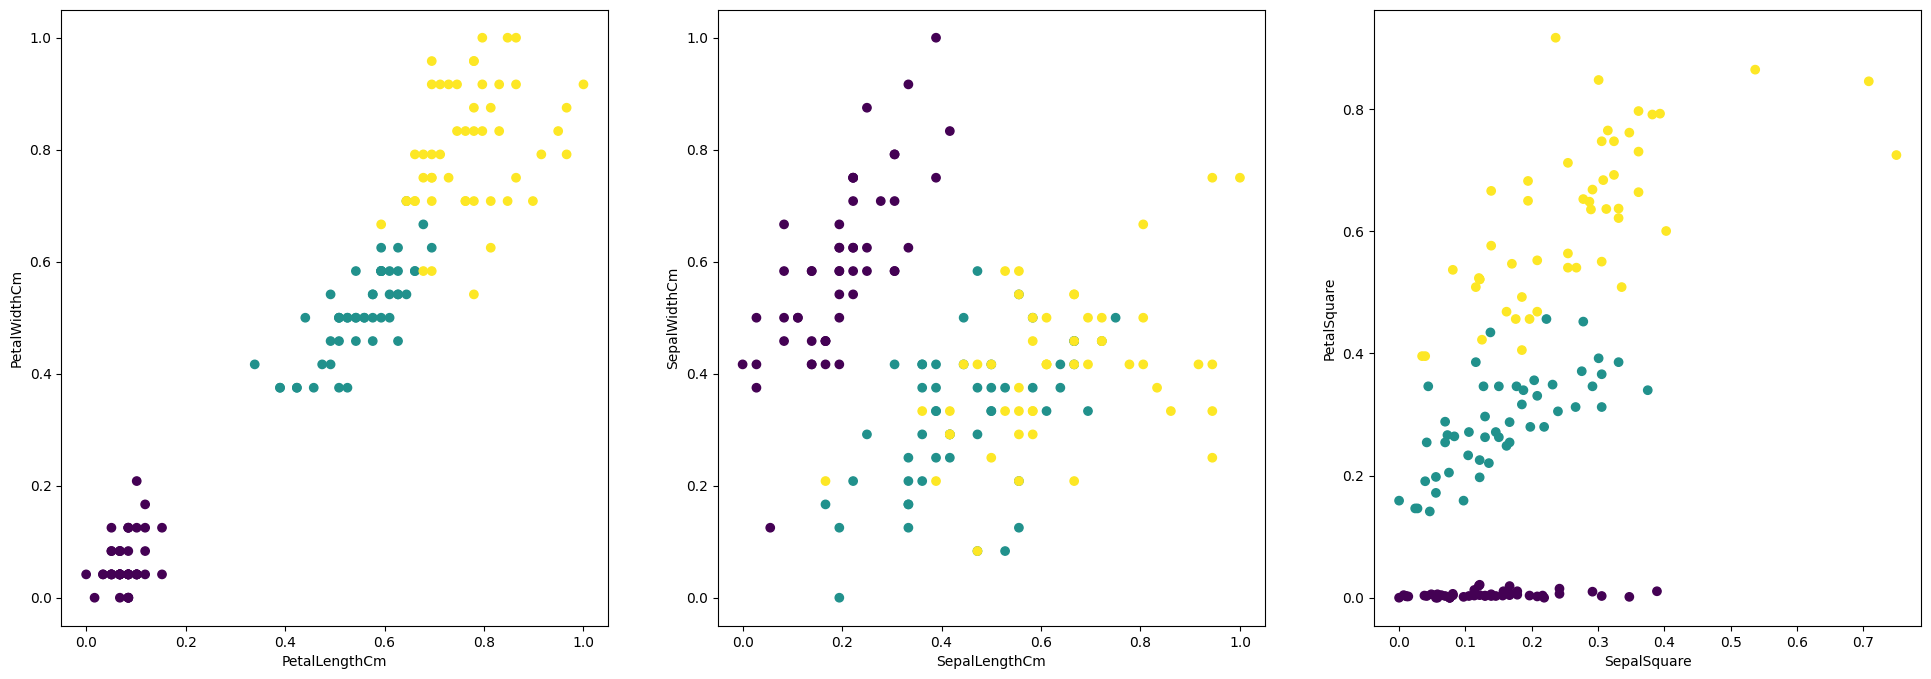

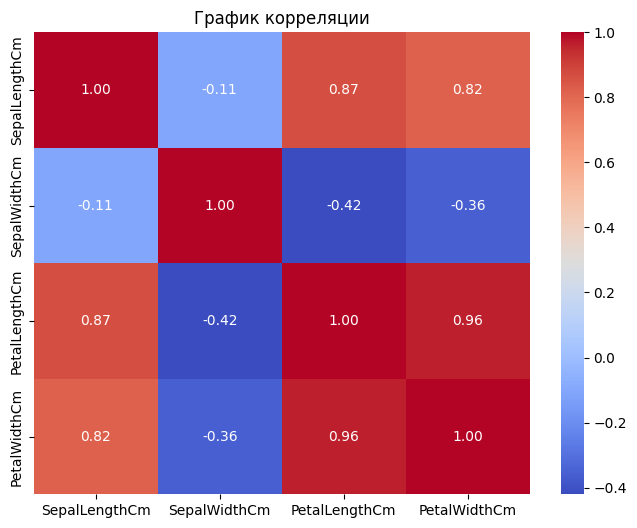

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(24,8))

axes[0].scatter(X['PetalLengthCm'], X['PetalWidthCm'], c=y['Species'], cmap='viridis')
axes[0].set_xlabel('PetalLengthCm')
axes[0].set_ylabel('PetalWidthCm')

axes[1].scatter(X['SepalLengthCm'], X['SepalWidthCm'], c=y['Species'], cmap='viridis')
axes[1].set_xlabel('SepalLengthCm')
axes[1].set_ylabel('SepalWidthCm')

axes[2].scatter(X['SepalSquare'], X['PetalSquare'], c=y['Species'], cmap='viridis')
axes[2].set_xlabel('SepalSquare')
axes[2].set_ylabel('PetalSquare')

plt.show()

corr_matrix = df[float_columns].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('График корреляции')
plt.show()

## 6. Обучение KNN

In [ ]:
class KNN():
    def __init__(self, k_neighbours = 3, metric = 'euclidean', weights = 'uniform', p = 2):
        self.k_neighbours = k_neighbours
        self.metric = metric
        self.weights = weights
        self.p = p
        self.distance = {
            'euclidean': lambda x, y: np.sqrt(np.sum((x - y) ** 2)),
            'manhattan': lambda x, y: np.sum(np.abs(x - y)),
            'minkowski': lambda x, y: np.power(np.sum(np.power(np.abs(x - y), self.p)), 1/self.p)
        }[metric]
        
    def fit(self, X, y):
        self.X_train = X
        self.y_train = y
        self.classes = np.unique(y)
        self.predict_column = 'PetalSquare'
    
    def predict(self, X):
        predictions = []
        for x in X[self.predict_column]:
            distances = np.array([self.distance(x, x_train) for x_train in self.X_train[self.predict_column]])
            nearest_neighbours = distances.argsort()[:self.k_neighbours]
            nearest_distances = distances.sort()[:self.k_neighbours]
            nearest_labels = self.y_train.iloc[nearest_neighbours].values.ravel()
            if self.weights == 'uniform':
                predictions.append(np.argmax(np.bincount(nearest_labels)))
            elif self.weights == 'distance':
                sums = np.zeros(len(self.classes))
                for i, label in enumerate(nearest_neighbours):
                    sums[label] += nearest_distances[i]
                predictions.append(np.argmax(sums))
        return np.array(predictions)  
            
    def score(self, X, y):
        return np.mean(self.predict(X) == np.array(y['Species']))

## 7. Тестирование и визуализация

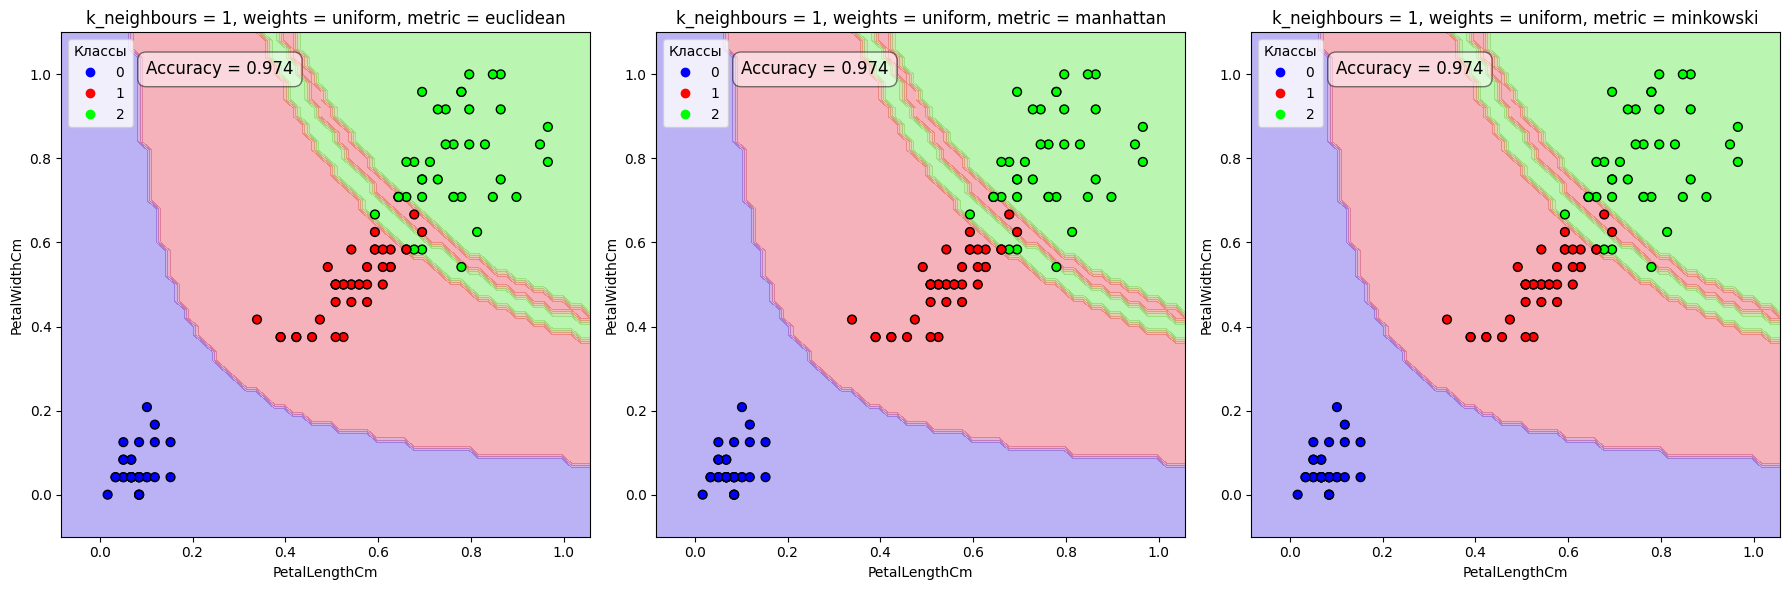

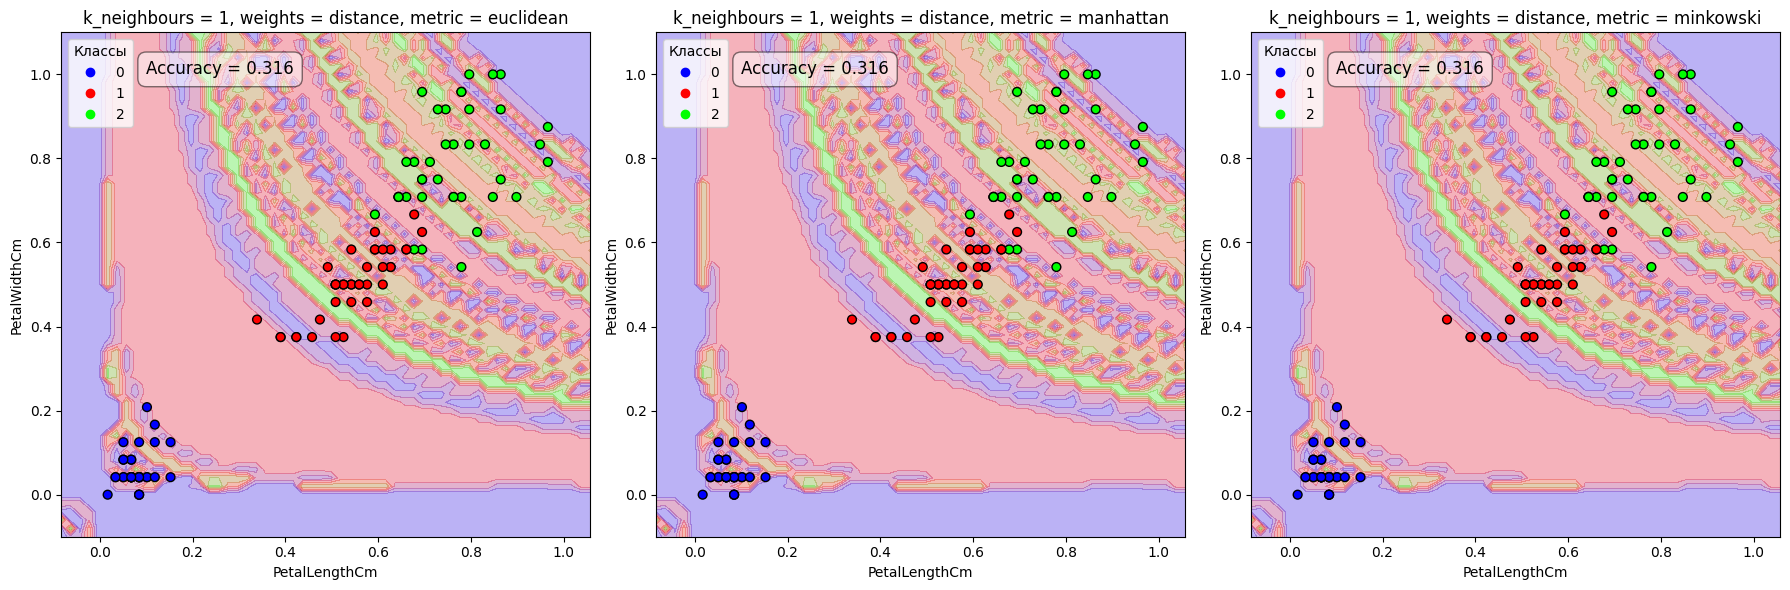

KeyboardInterrupt: 

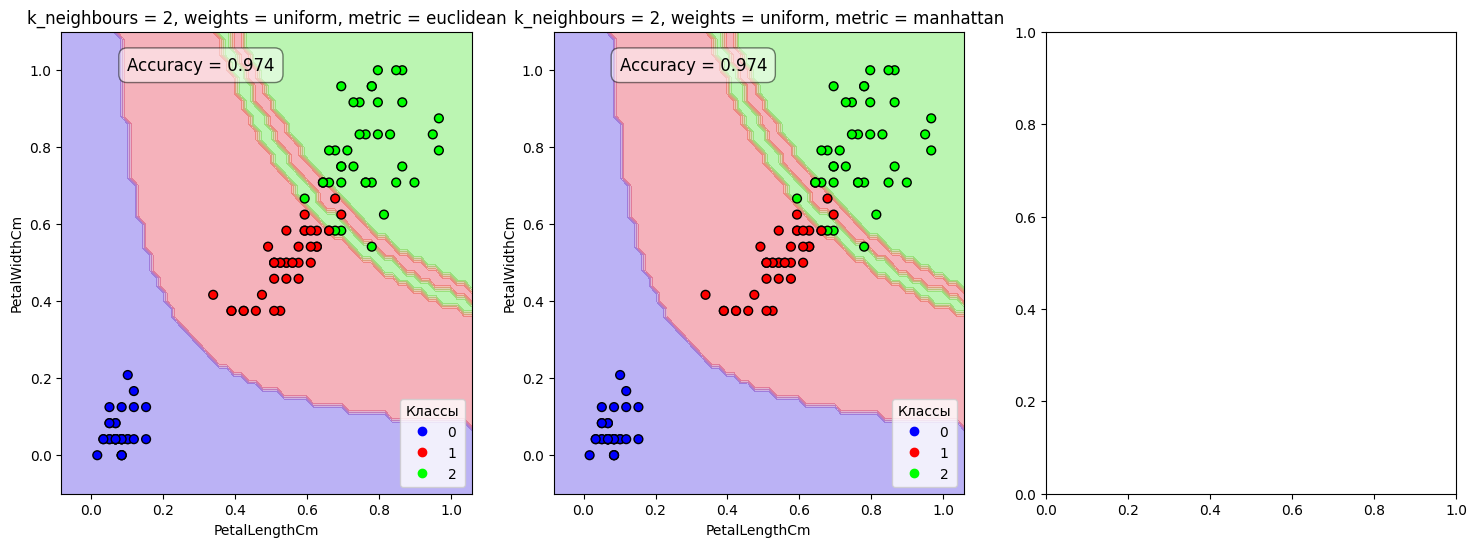

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

def plot_decision(axs, i, X, y, model, h = 0.02):
    x_min, x_max = X['PetalLengthCm'].min(), X['PetalLengthCm'].max() 
    y_min, y_max = X['PetalWidthCm'].min(), X['PetalWidthCm'].max()
    
    x_range = np.arange(x_min - 0.1, x_max + 0.1, h)
    y_range = np.arange(y_min - 0.1, y_max + 0.1, h)
    
    x_flat = np.repeat(x_range, len(y_range))
    y_flat = np.tile(y_range, len(x_range))
    
    squares = x_flat * y_flat
    
    df_plot = pd.DataFrame({
        'Id': np.arange(1, len(x_flat) + 1),
        'PetalLengthCm': x_flat,
        'PetalWidthCm': y_flat,
        'PetalSquare': squares,
    })
    
    Z = model.predict(df_plot)
    Z_matrix = Z.reshape(len(x_range), len(y_range))
    # plt.figure(figsize=(8, 6))
    axs[i].contourf(x_range, y_range, Z_matrix.T, alpha=0.3, cmap='brg')
    scatter = axs[i].scatter(X['PetalLengthCm'], X['PetalWidthCm'], c = y['Species'], edgecolors='k', cmap='brg', s=40)
    axs[i].set_xlabel('PetalLengthCm')
    axs[i].set_ylabel('PetalWidthCm')
    axs[i].legend(*scatter.legend_elements(), title="Классы")
    
for k_neighbours in range(1, 21):
    for weights in ['uniform', 'distance']:
        fig, axs = plt.subplots(1, 3, figsize=(18,6))
        for i, metric in enumerate(['euclidean', 'manhattan', 'minkowski']):
            model = KNN(k_neighbours, metric, weights)
            model.fit(X_train, y_train)
            
            plot_decision(axs, i, X_train, y_train, model)
            
            axs[i].text(0.1, 1, f"Accuracy = {model.score(X_test, y_test):.3f}", fontsize=12,
                            bbox=dict(facecolor='white',
                            edgecolor='black',
                            boxstyle='round,pad=0.5',
                            alpha=0.5))
            axs[i].set_title(f"k_neighbours = {k_neighbours}, weights = {weights}, metric = {metric}")
            
        plt.tight_layout()
        plt.show()